# Nonlinear LQR — Tracking, iLQR, and DDP

In the previous notebook, we studied Dynamic Programming and LQR.

For linear dynamics:

$$
x_{k+1}=Ax_k+Bu_k
$$

and quadratic costs, the value function has the structured form:

$$
V_k(x)=x^TP_kx.
$$

This leads to the feedback policy:

$$
u_k=-K_kx_k.
$$

However, many robotic systems have nonlinear dynamics:

$$
x_{k+1}=f(x_k,u_k).
$$

The goal of this notebook is to understand how LQR ideas can be extended to tracking and nonlinear optimal control.

We will progress through:

$$
\boxed{
\text{LQR}
\rightarrow
\text{Linear Tracking}
\rightarrow
\text{Nonlinear Tracking}
\rightarrow
\text{iLQR}
\rightarrow
\text{DDP}
}
$$

## 1. Linear Trajectory Tracking

Suppose we are given a nominal state trajectory:

$$
\bar{x}_0,\bar{x}_1,\ldots,\bar{x}_N
$$

and nominal controls:

$$
\bar{u}_0,\bar{u}_1,\ldots,\bar{u}_{N-1}.
$$

The objective is no longer simply to regulate:

$$
x_k \rightarrow 0.
$$

Instead, we want:

$$
x_k \rightarrow \bar{x}_k
$$

and:

$$
u_k \rightarrow \bar{u}_k.
$$

Define the deviation variables:

$$
\boxed{
\delta x_k=x_k-\bar{x}_k
}
$$

and:

$$
\boxed{
\delta u_k=u_k-\bar{u}_k.
}
$$

The tracking problem can then be interpreted as regulating the deviations:

$$
\delta x_k \rightarrow 0.
$$

### Tracking Feedback Law

Applying LQR to the deviation variables gives:

$$
\delta u_k=-K_k\delta x_k.
$$

Since:

$$
\delta u_k=u_k-\bar{u}_k,
$$

we obtain:

$$
u_k-\bar{u}_k=
-K_k(x_k-\bar{x}_k).
$$

Therefore:

$$
\boxed{
u_k=
\bar{u}_k-
K_k(x_k-\bar{x}_k)
}
$$

The control therefore consists of:

$$
\boxed{
\text{nominal control}
+
\text{feedback correction}.
}
$$

The nominal control attempts to follow the planned trajectory, while the feedback term corrects deviations from it.

## 2. Nonlinear Tracking Through Local Linearization

Consider nonlinear discrete-time dynamics:

$$
x_{k+1}=f(x_k,u_k).
$$

Suppose a feasible nominal trajectory is available:

$$
\bar{x}_0,\ldots,\bar{x}_N
$$

and:

$$
\bar{u}_0,\ldots,\bar{u}_{N-1}.
$$

Because the nominal trajectory is feasible:

$$
\bar{x}_{k+1}=
f(\bar{x}_k,\bar{u}_k).
$$

Define deviations from the nominal trajectory:

$$
\delta x_k=x_k-\bar{x}_k
$$

and:

$$
\delta u_k=u_k-\bar{u}_k.
$$

We now linearize the nonlinear dynamics around the nominal state and control.

### Local Linear Error Dynamics

Using a first-order Taylor expansion:

$$
f(x_k,u_k)
\approx
f(\bar{x}_k,\bar{u}_k)
+
A_k(x_k-\bar{x}_k)
+
B_k(u_k-\bar{u}_k),
$$

where:

$$
\boxed{
A_k=
\left.
\frac{\partial f}{\partial x}
\right|_{\bar{x}_k,\bar{u}_k}
}
$$

and:

$$
\boxed{
B_k=
\left.
\frac{\partial f}{\partial u}
\right|_{\bar{x}_k,\bar{u}_k}.
}
$$

Since the nominal trajectory satisfies:

$$
\bar{x}_{k+1}=
f(\bar{x}_k,\bar{u}_k),
$$

the deviation dynamics become:

$$
\boxed{
\delta x_{k+1}
\approx
A_k\delta x_k
+
B_k\delta u_k.
}
$$

Therefore, although the original system is nonlinear, the deviations around the nominal trajectory follow approximately linear dynamics.

## 3. Local Quadratic Approximation of the Cost

Suppose the running cost is:

$$
\ell(x_k,u_k).
$$

For nonlinear optimal-control problems, this cost does not have to be globally quadratic.

Around the nominal point:

$$
(\bar{x}_k,\bar{u}_k),
$$

we approximate it using a second-order Taylor expansion.

Define:

$$
\delta x_k=x_k-\bar{x}_k
$$

and:

$$
\delta u_k=u_k-\bar{u}_k.
$$

Then the local approximation can be written as:

$$
\ell(x_k,u_k)
\approx
\ell_k
+
\ell_x^T\delta x_k
+
\ell_u^T\delta u_k
+
\frac{1}{2}\delta x_k^T\ell_{xx}\delta x_k
+
\delta x_k^T\ell_{xu}\delta u_k
+
\frac{1}{2}\delta u_k^T\ell_{uu}\delta u_k.
$$

The derivatives are evaluated at the nominal state and control:

$$
(\bar{x}_k,\bar{u}_k).
$$

### Local LQR-Like Problem

Around the nominal trajectory, the nonlinear problem is approximated by:

$$
\delta x_{k+1}
\approx
A_k\delta x_k+B_k\delta u_k
$$

with a locally quadratic cost.

Therefore, each local approximation has the same basic structure as an LQR problem:

$$
\boxed{
\text{linear dynamics}
+
\text{quadratic cost}.
}
$$

This allows Dynamic Programming and LQR-style backward recursion to be applied locally.

## 4. Feedforward and Feedback Corrections

In ordinary LQR, the feedback controller has the form:

$$
u_k=-K_kx_k.
$$

For trajectory tracking around a nominal trajectory, we obtained:

$$
u_k=
\bar{u}_k-
K_k(x_k-\bar{x}_k).
$$

In iLQR, however, the nominal control trajectory itself may not yet be optimal.

Therefore, two different corrections are required:

$$
\boxed{
\delta u_k=
k_k
+
K_k\delta x_k
}
$$

where:

$$
\delta x_k=x_k-\bar{x}_k.
$$

The term:

$$
\boxed{k_k}
$$

is the **feedforward correction**. It improves the nominal control trajectory itself.

The term:

$$
\boxed{K_k\delta x_k}
$$

is the **feedback correction**. It responds to deviations from the nominal state trajectory.

Therefore, the updated control can be written as:

$$
\boxed{
u_k^{new}=
\bar{u}_k
+
\alpha k_k
+
K_k(x_k^{new}-\bar{x}_k)
}
$$

where $\alpha$ controls the size of the feedforward update.

### Interpretation

The two control corrections have different roles.

The feedforward term:

$$
k_k
$$

changes the nominal control even when the system lies exactly on the nominal trajectory.

It therefore answers:

> How should the current nominal control trajectory be improved?

The feedback term:

$$
K_k\delta x_k
$$

responds to deviations from the nominal trajectory.

It answers:

> How should the controller react when the actual state differs from the nominal state?

Thus:

$$
\boxed{
k_k
\rightarrow
\text{trajectory improvement}
}
$$

and:

$$
\boxed{
K_k
\rightarrow
\text{feedback stabilization}.
}
$$

## 5. iLQR — Overall Algorithm

iLQR repeatedly improves a nominal trajectory.

### Initial guess

Choose an initial control sequence:

$$
\bar{U}=
\{\bar{u}_0,\ldots,\bar{u}_{N-1}\}.
$$

Roll out the nonlinear dynamics to obtain the nominal state trajectory:

$$
\bar{x}_{k+1}=
f(\bar{x}_k,\bar{u}_k).
$$

### Backward pass

Around the nominal trajectory:

1. linearize the nonlinear dynamics,
2. quadratize the cost,
3. perform an LQR-like Dynamic Programming recursion,
4. compute feedforward corrections $k_k$,
5. compute feedback gains $K_k$.

### Forward pass

Update the controls using:

$$
u_k^{new}=
\bar{u}_k
+
\alpha k_k
+
K_k(x_k^{new}-\bar{x}_k).
$$

Propagate the full nonlinear dynamics:

$$
x_{k+1}^{new}=
f(x_k^{new},u_k^{new}).
$$

The resulting trajectory becomes the new nominal trajectory.

Repeat until the cost no longer improves significantly.

Therefore:

$$
\boxed{
\text{rollout}
\rightarrow
\text{local approximation}
\rightarrow
\text{backward pass}
\rightarrow
\text{forward update}
\rightarrow
\text{repeat}
}
$$

## 6. iLQR Backward Pass — Local Q-Function

Recall the Bellman recursion:

$$
V_k(x_k)=
\min_{u_k}
\left[
\ell(x_k,u_k)
+
V_{k+1}(x_{k+1})
\right].
$$

For iLQR, we work with deviations around the current nominal trajectory:

$$
\delta x_k=x_k-\bar{x}_k
$$

and:

$$
\delta u_k=u_k-\bar{u}_k.
$$

Define the local Q-function as:

$$
Q_k(\delta x_k,\delta u_k)=
\ell(x_k,u_k)
+
V_{k+1}(x_{k+1}).
$$

The local Q-function represents the cost of:

1. applying a control correction at the current timestep,
2. followed by optimal behavior from the next timestep onward.

### Quadratic Approximation of the Local Q-Function

Around the nominal trajectory, the local Q-function is approximated as:

$$
Q_k(\delta x,\delta u)
\approx
Q_0
+
Q_x^T\delta x
+
Q_u^T\delta u
+
\frac{1}{2}\delta x^TQ_{xx}\delta x
+
\delta x^TQ_{xu}\delta u
+
\frac{1}{2}\delta u^TQ_{uu}\delta u.
$$

The terms have intuitive meanings:

$$
Q_x,\;Q_u
$$

describe the local slope of future cost with respect to state and control, while:

$$
Q_{xx},\;Q_{uu},\;Q_{xu}
$$

describe the local curvature.

### Optimal Local Control Correction

To minimize the local Q-function with respect to the control correction:

$$
\frac{\partial Q}{\partial \delta u}=0.
$$

This gives:

$$
Q_u
+
Q_{uu}\delta u
+
Q_{ux}\delta x=
0.
$$

Solving for $\delta u$:

$$
\delta u^*=
-Q_{uu}^{-1}Q_u-
Q_{uu}^{-1}Q_{ux}\delta x.
$$

Define the feedforward correction:

$$
\boxed{
k_k=-Q_{uu}^{-1}Q_u
}
$$

and the feedback gain:

$$
\boxed{
K_k=-Q_{uu}^{-1}Q_{ux}.
}
$$

Therefore:

$$
\boxed{
\delta u_k^*=
k_k+K_k\delta x_k.
}
$$

### Local Q-Function Derivatives

Using the locally linear dynamics:

$$
\delta x_{k+1}
\approx
A_k\delta x_k+B_k\delta u_k,
$$

the local Q-function derivatives are:

$$
Q_x=
\ell_x+A_k^TV_x'
$$

$$
Q_u=
\ell_u+B_k^TV_x'
$$

$$
Q_{xx}=
\ell_{xx}+A_k^TV_{xx}'A_k
$$

$$
Q_{uu}=
\ell_{uu}+B_k^TV_{xx}'B_k
$$

$$
Q_{ux}=
\ell_{ux}+B_k^TV_{xx}'A_k.
$$

Here:

$$
V_x'=V_{x,k+1}
$$

and:

$$
V_{xx}'=V_{xx,k+1}.
$$

These quantities carry the cost-to-go information backward through the trajectory.

## 7. Updating the Local Value Function

After computing the optimal local control correction:

$$
\delta u_k^*=
k_k+K_k\delta x_k,
$$

we substitute it back into the local quadratic Q-function.

This gives a new local approximation of the value function:

$$
V_k(\delta x_k)
\approx
V_0
+
V_x^T\delta x_k
+
\frac{1}{2}
\delta x_k^TV_{xx}\delta x_k.
$$

The derivatives of this value function are then propagated to the previous timestep.

The resulting updates are:

$$
\boxed{
V_x=
Q_x
+
K_k^TQ_{uu}k_k
+
K_k^TQ_u
+
Q_{xu}k_k
}
$$

and:

$$
\boxed{
V_{xx}=
Q_{xx}
+
K_k^TQ_{uu}K_k
+
K_k^TQ_{ux}
+
Q_{xu}K_k.
}
$$

These quantities summarize the locally optimal future cost and allow the backward recursion to continue.

### Complete iLQR Backward Step

At timestep $k$, assume the value-function derivatives from timestep $k+1$ are known:

$$
V_x',\qquad V_{xx}'.
$$

First compute the local dynamics:

$$
A_k=
\frac{\partial f}{\partial x},
\qquad
B_k=
\frac{\partial f}{\partial u}.
$$

Then compute the local Q-function derivatives:

$$
Q_x=\ell_x+A_k^TV_x'
$$

$$
Q_u=\ell_u+B_k^TV_x'
$$

$$
Q_{xx}=
\ell_{xx}+A_k^TV_{xx}'A_k
$$

$$
Q_{uu}=
\ell_{uu}+B_k^TV_{xx}'B_k
$$

$$
Q_{ux}=
\ell_{ux}+B_k^TV_{xx}'A_k.
$$

The optimal local control law is:

$$
\boxed{
\delta u_k=k_k+K_k\delta x_k
}
$$

with:

$$
\boxed{
k_k=-Q_{uu}^{-1}Q_u
}
$$

and:

$$
\boxed{
K_k=-Q_{uu}^{-1}Q_{ux}.
}
$$

Finally, update the local value-function derivatives:

$$
V_x=
Q_x
+
K_k^TQ_{uu}k_k
+
K_k^TQ_u
+
Q_{xu}k_k
$$

and:

$$
V_{xx}=
Q_{xx}
+
K_k^TQ_{uu}K_k
+
K_k^TQ_{ux}
+
Q_{xu}K_k.
$$

The recursion then moves to timestep $k-1$.

### Terminal Condition

The backward pass starts from the terminal cost:

$$
\phi(x_N).
$$

At the nominal terminal state:

$$
\bar{x}_N,
$$

initialize:

$$
\boxed{
V_x=
\frac{\partial\phi}{\partial x}
}
$$

and:

$$
\boxed{
V_{xx}=
\frac{\partial^2\phi}{\partial x^2}.
}
$$

The backward recursion then computes:

$$
(k_{N-1},K_{N-1}),
\ldots,
(k_0,K_0).
$$

## Case Study

### iLQR for a Nonlinear 2D Car

We now apply iLQR to the nonlinear kinematic bicycle model.

The requirement is:

> Move the vehicle from a known initial state toward a desired target state over a finite horizon while minimizing unnecessary acceleration and steering.

Unlike the previous LQR tracking example, we will use the nonlinear vehicle dynamics directly.

The state is:

$$
x=
\begin{bmatrix}
p_x\\
p_y\\
\theta\\
v
\end{bmatrix}
$$

and the control is:

$$
u=
\begin{bmatrix}
a\\
\delta
\end{bmatrix}.
$$

The continuous-time kinematic bicycle model is:

$$
\dot p_x=v\cos\theta
$$

$$
\dot p_y=v\sin\theta
$$

$$
\dot\theta=\frac{v}{L}\tan\delta
$$

$$
\dot v=a.
$$

Using Forward Euler, the discrete nonlinear dynamics are:

$$
\boxed{
x_{k+1}=f(x_k,u_k)
}
$$

with:

$$
p_{x,k+1}=
p_{x,k}
+
\Delta t\,v_k\cos\theta_k
$$

$$
p_{y,k+1}=
p_{y,k}
+
\Delta t\,v_k\sin\theta_k
$$

$$
\theta_{k+1}=
\theta_k
+
\Delta t\frac{v_k}{L}\tan\delta_k
$$

$$
v_{k+1}=
v_k+\Delta t\,a_k.
$$

In [1]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Vehicle parameters
L = 2.5
dt = 0.1

# Horizon
N = 50

def dynamics(x, u):
    px, py, theta, v = x
    a, delta = u

    x_next = jnp.array([
        px + dt * v * jnp.cos(theta),
        py + dt * v * jnp.sin(theta),
        theta + dt * (v / L) * jnp.tan(delta),
        v + dt * a
    ])

    return x_next

In [2]:
A_fn = jax.jacfwd(dynamics, argnums=0)
B_fn = jax.jacfwd(dynamics, argnums=1)

### Cost Function

We separate the objective into a running cost and a terminal cost:

$$
J=
\sum_{k=0}^{N-1}
\ell(x_k,u_k)
+
\phi(x_N).
$$

The running cost penalizes control effort:

$$
\ell(x_k,u_k)=
w_a a_k^2
+
w_\delta \delta_k^2.
$$

The terminal cost penalizes deviation from the desired final state:

$$
\phi(x_N)=
(x_N-x_{\text{goal}})^T
Q_f
(x_N-x_{\text{goal}}).
$$

Thus the optimizer must balance:

$$
\boxed{
\text{reaching the target}
+
\text{control effort}.
}
$$

In [3]:
# Initial state
x0 = jnp.array([
    0.0,   # px
    0.0,   # py
    0.0,   # heading
    2.0    # speed
])

# Desired terminal state
x_goal = jnp.array([
    8.0,                 # px
    4.0,                 # py
    jnp.deg2rad(30.0),   # heading
    2.0                  # speed
])

# Running-cost weights
w_a = 0.1
w_delta = 0.5

# Terminal-cost weights
Qf = jnp.diag(
    jnp.array([20.0, 20.0, 10.0, 5.0])
)

In [4]:
def running_cost(x, u):
    a, delta = u

    return (
        w_a * a**2
        + w_delta * delta**2
    )


def terminal_cost(x):
    error = x - x_goal
    return error @ Qf @ error

In [5]:
# First derivatives
lx_fn = jax.grad(running_cost, argnums=0)
lu_fn = jax.grad(running_cost, argnums=1)

# Second derivatives
lxx_fn = jax.hessian(running_cost, argnums=0)
luu_fn = jax.hessian(running_cost, argnums=1)

# Mixed derivative
lux_fn = jax.jacfwd(
    jax.grad(running_cost, argnums=1),
    argnums=0
)

# Terminal derivatives
phix_fn = jax.grad(terminal_cost)
phixx_fn = jax.hessian(terminal_cost)

### Initial Nominal Trajectory

iLQR requires an initial nominal control sequence.

We begin with a simple guess:

$$
\bar{u}_k=
\begin{bmatrix}
0\\
0
\end{bmatrix}.
$$

The corresponding nominal state trajectory is obtained by rolling these controls through the nonlinear dynamics:

$$
\bar{x}_{k+1}=
f(\bar{x}_k,\bar{u}_k).
$$

This initial trajectory does not need to be optimal.

iLQR will iteratively improve it.

In [6]:
U_bar = jnp.zeros((N, 2))


def rollout(x0, U):
    X = [x0]
    x = x0

    for k in range(N):
        x = dynamics(x, U[k])
        X.append(x)

    return jnp.stack(X)


X_bar = rollout(x0, U_bar)

print("Initial state:")
print(X_bar[0])

print("\nInitial terminal state:")
print(X_bar[-1])

print("\nDesired terminal state:")
print(x_goal)

Initial state:
[0. 0. 0. 2.]

Initial terminal state:
[9.999995 0.       0.       2.      ]

Desired terminal state:
[8.        4.        0.5235988 2.       ]


### iLQR Backward Pass

Given the current nominal trajectory:

$$
\bar{X},\bar{U},
$$

the backward pass proceeds from:

$$
k=N-1
$$

to:

$$
k=0.
$$

At every timestep:

1. linearize the nonlinear dynamics,
2. compute first- and second-order cost derivatives,
3. construct the local Q-function derivatives,
4. compute the feedforward correction $k_k$,
5. compute the feedback gain $K_k$,
6. propagate the local value function backward.

The result is a sequence:

$$
k_0,\ldots,k_{N-1}
$$

and:

$$
K_0,\ldots,K_{N-1}.
$$

In [7]:
def total_cost(X, U):
    cost = 0.0

    for k in range(N):
        cost += running_cost(X[k], U[k])

    cost += terminal_cost(X[-1])

    return cost

In [8]:
nx = 4
nu = 2


def backward_pass(X_bar, U_bar, regularization=1e-5):

    # Feedforward and feedback terms
    k_ff = np.zeros((N, nu))
    K_fb = np.zeros((N, nu, nx))

    # Terminal value-function derivatives
    Vx = np.array(phix_fn(X_bar[-1]))
    Vxx = np.array(phixx_fn(X_bar[-1]))

    for k in reversed(range(N)):

        x = X_bar[k]
        u = U_bar[k]

        # Local linearization of dynamics
        A = np.array(A_fn(x, u))
        B = np.array(B_fn(x, u))

        # Running-cost derivatives
        lx = np.array(lx_fn(x, u))
        lu = np.array(lu_fn(x, u))

        lxx = np.array(lxx_fn(x, u))
        luu = np.array(luu_fn(x, u))
        lux = np.array(lux_fn(x, u))

        # Local Q-function derivatives
        Qx = lx + A.T @ Vx
        Qu = lu + B.T @ Vx

        Qxx = lxx + A.T @ Vxx @ A
        Quu = luu + B.T @ Vxx @ B
        Qux = lux + B.T @ Vxx @ A

        # Small regularization for numerical stability
        Quu_reg = Quu + regularization * np.eye(nu)

        # Feedforward correction
        k_k = -np.linalg.solve(
            Quu_reg,
            Qu
        )

        # Feedback gain
        K_k = -np.linalg.solve(
            Quu_reg,
            Qux
        )

        k_ff[k] = k_k
        K_fb[k] = K_k

        # Update value-function derivatives
        Vx = (
            Qx
            + K_k.T @ Quu @ k_k
            + K_k.T @ Qu
            + Qux.T @ k_k
        )

        Vxx = (
            Qxx
            + K_k.T @ Quu @ K_k
            + K_k.T @ Qux
            + Qux.T @ K_k
        )

        # Numerical symmetry
        Vxx = 0.5 * (Vxx + Vxx.T)

    return k_ff, K_fb

### Backward-Pass Interpretation

The backward pass propagates future-cost information from the terminal state toward the beginning of the trajectory.

At each timestep:

$$
(V_x,V_{xx})_{k+1}
$$

is combined with the local dynamics and cost derivatives to construct:

$$
Q_x,\;Q_u,\;Q_{xx},\;Q_{uu},\;Q_{ux}.
$$

These determine:

$$
\boxed{
k_k=-Q_{uu}^{-1}Q_u
}
$$

and:

$$
\boxed{
K_k=-Q_{uu}^{-1}Q_{ux}.
}
$$

The value-function derivatives are then updated and propagated to the previous timestep.

Thus:

$$
\boxed{
(V_x,V_{xx})_{k+1}
\rightarrow
Q\text{-derivatives}
\rightarrow
(k_k,K_k)
\rightarrow
(V_x,V_{xx})_k
}
$$

In [9]:
k_ff, K_fb = backward_pass(X_bar, U_bar)

print("Feedforward shape:", k_ff.shape)
print("Feedback shape:   ", K_fb.shape)

print("\nFirst feedforward correction:")
print(k_ff[0])

print("\nFirst feedback matrix:")
print(K_fb[0])

Feedforward shape: (50, 2)
Feedback shape:    (50, 2, 4)

First feedforward correction:
[-0.43800376  0.32574623]

First feedback matrix:
[[-0.2190024  -0.         -0.         -0.7713917 ]
 [-0.         -0.11933073 -0.90381721 -0.        ]]


### iLQR Forward Pass

After the backward pass, we have:

$$
k_k
$$

and:

$$
K_k.
$$

Starting again from the true initial state:

$$
x_0,
$$

the updated control is:

$$
\boxed{
u_k^{new}=
\bar{u}_k
+
\alpha k_k
+
K_k(x_k^{new}-\bar{x}_k).
}
$$

The new state is obtained using the full nonlinear dynamics:

$$
\boxed{
x_{k+1}^{new}=
f(x_k^{new},u_k^{new}).
}
$$

The parameter $\alpha$ determines how strongly the feedforward update is applied.

In [10]:
def forward_pass(
    x0,
    X_bar,
    U_bar,
    k_ff,
    K_fb,
    alpha=1.0
):

    X_new = [x0]
    U_new = []

    x = x0

    for k in range(N):

        dx = np.array(x - X_bar[k])

        u = (
            np.array(U_bar[k])
            + alpha * k_ff[k]
            + K_fb[k] @ dx
        )

        u = jnp.array(u)

        x = dynamics(x, u)

        U_new.append(u)
        X_new.append(x)

    return (
        jnp.stack(X_new),
        jnp.stack(U_new)
    )

In [11]:
initial_cost = float(total_cost(X_bar, U_bar))

X_new, U_new = forward_pass(
    x0,
    X_bar,
    U_bar,
    k_ff,
    K_fb,
    alpha=1.0
)

new_cost = float(total_cost(X_new, U_new))

print("Initial cost:", initial_cost)
print("New cost:    ", new_cost)

Initial cost: 402.7411804199219
New cost:     11.357044219970703


### Line Search

The iLQR backward pass is based on a local approximation of the nonlinear problem.

Therefore, applying the full feedforward update:

$$
\alpha=1
$$

may move the new trajectory too far from the nominal trajectory.

To improve robustness, we try several step sizes:

$$
\alpha \in
\{1.0,\;0.5,\;0.25,\;0.1,\;0.05\}.
$$

For each candidate $\alpha$:

1. perform a forward rollout using the full nonlinear dynamics,
2. evaluate the true trajectory cost,
3. accept the first update that reduces the cost.

Thus, line search helps ensure that each accepted iLQR iteration actually improves the nonlinear objective.

In [12]:
alphas = [1.0, 0.5, 0.25, 0.1, 0.05]


def line_search(
    x0,
    X_bar,
    U_bar,
    k_ff,
    K_fb
):

    old_cost = float(total_cost(X_bar, U_bar))

    for alpha in alphas:

        X_candidate, U_candidate = forward_pass(
            x0,
            X_bar,
            U_bar,
            k_ff,
            K_fb,
            alpha=alpha
        )

        candidate_cost = float(
            total_cost(X_candidate, U_candidate)
        )

        if candidate_cost < old_cost:
            return (
                X_candidate,
                U_candidate,
                candidate_cost,
                alpha
            )

    # No improving step found
    return X_bar, U_bar, old_cost, 0.0

### Complete iLQR Algorithm

The complete iLQR procedure is:

#### Initialization

Choose an initial control trajectory:

$$
\bar{U}.
$$

Roll out the nonlinear dynamics:

$$
\bar{x}_{k+1}=
f(\bar{x}_k,\bar{u}_k).
$$

#### Iteration

Repeat:

1. perform the backward pass,
2. compute $k_k$ and $K_k$,
3. perform line search,
4. roll out the full nonlinear dynamics,
5. accept the new trajectory if the cost decreases.

The process stops when the improvement becomes sufficiently small or a maximum number of iterations is reached.

Therefore:

$$
\boxed{
\bar{U}
\rightarrow
\bar{X}
\rightarrow
\text{backward pass}
\rightarrow
(k,K)
\rightarrow
\text{line search}
\rightarrow
(X^{new},U^{new})
\rightarrow
\text{repeat}.
}
$$

In [13]:
def ilqr(
    x0,
    U_init,
    max_iterations=50,
    tolerance=1e-4
):

    U_bar = U_init
    X_bar = rollout(x0, U_bar)

    cost_history = [
        float(total_cost(X_bar, U_bar))
    ]

    for iteration in range(max_iterations):

        # Backward pass
        k_ff, K_fb = backward_pass(
            X_bar,
            U_bar
        )

        # Forward pass + line search
        X_new, U_new, new_cost, alpha = line_search(
            x0,
            X_bar,
            U_bar,
            k_ff,
            K_fb
        )

        old_cost = cost_history[-1]
        improvement = old_cost - new_cost

        print(
            f"Iteration {iteration:2d} | "
            f"cost = {new_cost:10.4f} | "
            f"improvement = {improvement:10.4f} | "
            f"alpha = {alpha}"
        )

        # Stop if line search cannot improve
        if alpha == 0.0:
            print("No improving step found.")
            break

        X_bar = X_new
        U_bar = U_new

        cost_history.append(new_cost)

        # Convergence test
        if improvement < tolerance:
            print("Converged.")
            break

    return X_bar, U_bar, np.array(cost_history)

In [14]:
U_init = jnp.zeros((N, 2))

X_opt, U_opt, cost_history = ilqr(
    x0,
    U_init,
    max_iterations=50
)

Iteration  0 | cost =    11.3570 | improvement =   391.3841 | alpha = 1.0
Iteration  1 | cost =     1.4128 | improvement =     9.9442 | alpha = 1.0
Iteration  2 | cost =     1.2973 | improvement =     0.1155 | alpha = 1.0
Iteration  3 | cost =     1.2966 | improvement =     0.0006 | alpha = 1.0
Iteration  4 | cost =     1.2966 | improvement =     0.0000 | alpha = 1.0
Converged.


### Iterative Improvement

Each accepted iLQR iteration produces a new nominal trajectory with lower cost.

The process can be viewed as repeatedly solving a local LQR-like approximation around the current trajectory.

Unlike ordinary LQR, the local model changes after every forward rollout because:

$$
A_k=
\frac{\partial f}{\partial x}
$$

and:

$$
B_k=
\frac{\partial f}{\partial u}
$$

are recomputed around the new nominal trajectory.

Therefore:

$$
\boxed{
\text{iLQR}=
\text{repeated local LQR around an evolving nonlinear trajectory}.
}
$$

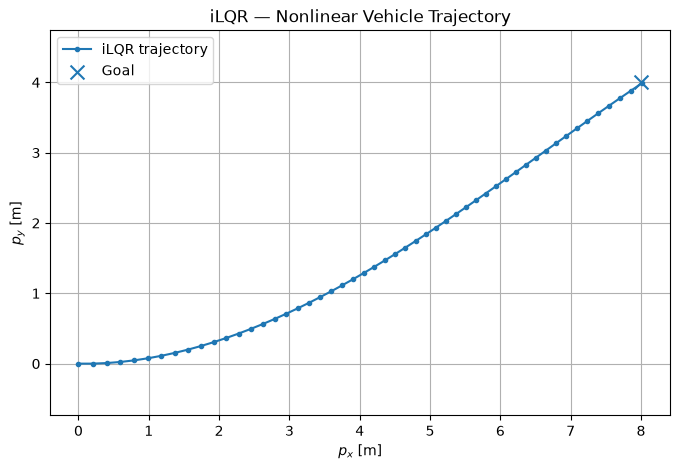

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.array(X_opt[:, 0]),
    np.array(X_opt[:, 1]),
    marker="o",
    markersize=3,
    label="iLQR trajectory"
)

plt.scatter(
    float(x_goal[0]),
    float(x_goal[1]),
    marker="x",
    s=100,
    label="Goal"
)

plt.xlabel("$p_x$ [m]")
plt.ylabel("$p_y$ [m]")
plt.title("iLQR — Nonlinear Vehicle Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

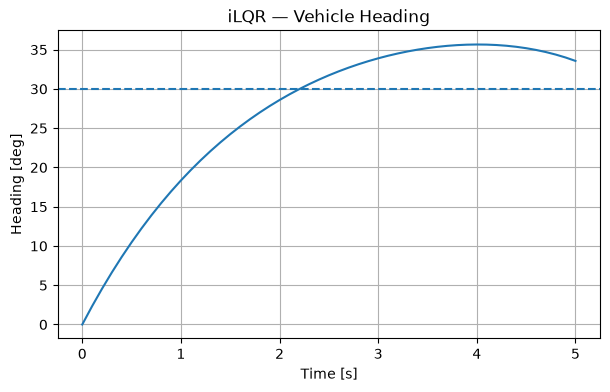

In [16]:
time = np.arange(N + 1) * dt

plt.figure(figsize=(7, 4))

plt.plot(
    time,
    np.rad2deg(np.array(X_opt[:, 2]))
)

plt.axhline(
    np.rad2deg(float(x_goal[2])),
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Heading [deg]")
plt.title("iLQR — Vehicle Heading")
plt.grid(True)
plt.show()

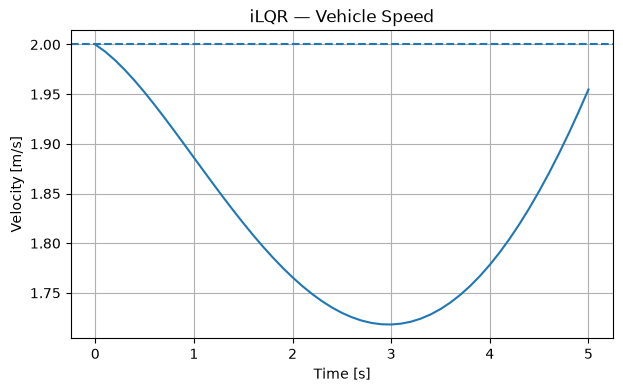

In [17]:
plt.figure(figsize=(7, 4))

plt.plot(
    time,
    np.array(X_opt[:, 3])
)

plt.axhline(
    float(x_goal[3]),
    linestyle="--"
)

plt.xlabel("Time [s]")
plt.ylabel("Velocity [m/s]")
plt.title("iLQR — Vehicle Speed")
plt.grid(True)
plt.show()

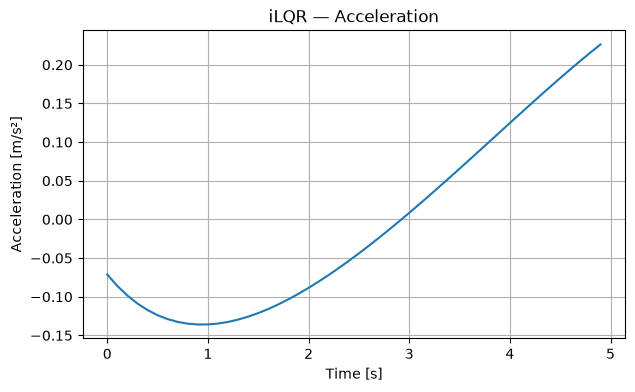

In [18]:
control_time = np.arange(N) * dt

plt.figure(figsize=(7, 4))

plt.plot(
    control_time,
    np.array(U_opt[:, 0])
)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [m/s²]")
plt.title("iLQR — Acceleration")
plt.grid(True)
plt.show()

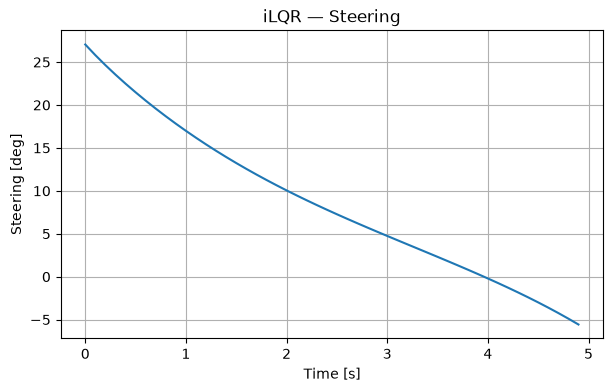

In [19]:
plt.figure(figsize=(7, 4))

plt.plot(
    control_time,
    np.rad2deg(np.array(U_opt[:, 1]))
)

plt.xlabel("Time [s]")
plt.ylabel("Steering [deg]")
plt.title("iLQR — Steering")
plt.grid(True)
plt.show()

### iLQR Result

The optimized trajectory is obtained through repeated local approximations of the nonlinear optimal-control problem.

At every iteration:

$$
\boxed{
\text{nonlinear trajectory}
\rightarrow
\text{local linear/quadratic model}
\rightarrow
\text{LQR-style backward pass}
\rightarrow
\text{nonlinear forward rollout}.
}
$$

The feedforward correction:

$$
k_k
$$

improves the nominal control trajectory, while the feedback gain:

$$
K_k
$$

provides local feedback around that trajectory.

Thus iLQR produces both:

$$
\boxed{
\text{trajectory optimization}
}
$$

and:

$$
\boxed{
\text{local feedback control}.
}
$$

### Validate the iLQR Solution

A decreasing objective alone is not sufficient to understand whether the optimized trajectory is useful.

We therefore inspect:

1. terminal state,
2. terminal error,
3. initial and final cost,
4. control magnitudes,
5. trajectory shape.

The terminal state should be close to:

$$
x_{\text{goal}}=
\begin{bmatrix}
8\\
4\\
30^\circ\\
2
\end{bmatrix}.
$$

In [20]:
terminal_state = np.array(X_opt[-1])
goal = np.array(x_goal)

terminal_error = terminal_state - goal

print("Optimized terminal state:")
print(terminal_state)

print("\nDesired terminal state:")
print(goal)

print("\nTerminal error:")
print(terminal_error)

print("\nPosition error [m]:")
print(np.linalg.norm(terminal_error[:2]))

print("\nHeading error [deg]:")
print(np.rad2deg(terminal_error[2]))

print("\nVelocity error [m/s]:")
print(terminal_error[3])

print("\nInitial cost:", cost_history[0])
print("Final cost:  ", cost_history[-1])

Optimized terminal state:
[8.015273   3.9888818  0.58586586 1.9547532 ]

Desired terminal state:
[8.        4.        0.5235988 2.       ]

Terminal error:
[ 0.01527309 -0.01111817  0.06226707 -0.04524684]

Position error [m]:
0.0188913

Heading error [deg]:
3.5676398

Velocity error [m/s]:
-0.04524684

Initial cost: 402.7411804199219
Final cost:   1.296600103378296


### Control Magnitudes

The optimized controls should also be inspected.

A trajectory can achieve low terminal error while requiring unrealistic control inputs.

Therefore, we inspect the maximum acceleration and steering magnitude.

In [21]:
U_np = np.array(U_opt)

print(
    "Maximum |acceleration| [m/s²]:",
    np.max(np.abs(U_np[:, 0]))
)

print(
    "Maximum |steering| [deg]:",
    np.rad2deg(np.max(np.abs(U_np[:, 1])))
)

Maximum |acceleration| [m/s²]: 0.22623427
Maximum |steering| [deg]: 27.046968


## 8. LQR vs iLQR

LQR assumes linear dynamics:

$$
x_{k+1}=Ax_k+Bu_k
$$

and quadratic costs.

The backward Riccati recursion is performed once, producing feedback gains:

$$
u_k=-K_kx_k.
$$

iLQR instead considers nonlinear dynamics:

$$
x_{k+1}=f(x_k,u_k).
$$

Around the current nominal trajectory, it constructs local linear models:

$$
\delta x_{k+1}
\approx
A_k\delta x_k+B_k\delta u_k
$$

and local quadratic approximations of the cost.

An LQR-like backward pass then produces:

$$
\delta u_k=
k_k+K_k\delta x_k.
$$

The full nonlinear system is rolled forward, producing a new nominal trajectory.

The process is repeated until convergence.

Therefore:

$$
\boxed{
\text{LQR}=
\text{one structured optimal-control solution}
}
$$

while:

$$
\boxed{
\text{iLQR}=
\text{iteratively solve local LQR-like problems}.
}
$$

## 9. Differential Dynamic Programming (DDP)

iLQR and DDP have the same broad structure:

$$
\boxed{
\text{nominal trajectory}
\rightarrow
\text{backward pass}
\rightarrow
\text{forward rollout}
\rightarrow
\text{repeat}.
}
$$

The important difference lies in how the local approximation is constructed.

### iLQR

iLQR first linearizes the nonlinear dynamics:

$$
\delta x_{k+1}
\approx
A_k\delta x_k+B_k\delta u_k.
$$

It then uses a quadratic approximation of the cost and performs an LQR-like Dynamic Programming recursion.

### DDP

DDP instead constructs a second-order approximation of the Dynamic Programming recursion itself.

This retains additional second-order information about the nonlinear dynamics.

Conceptually:

$$
\boxed{
\text{iLQR}
\rightarrow
\text{first-order dynamics approximation}
}
$$

while:

$$
\boxed{
\text{DDP}
\rightarrow
\text{includes second-order dynamics information}.
}
$$

### iLQR vs DDP

Both algorithms repeatedly improve a nominal trajectory using backward and forward passes.

The main distinction is the approximation used during the backward pass.

| Method | Dynamics information | Cost information |
|---|---|---|
| LQR | exact linear dynamics | exact quadratic cost |
| iLQR | first-order nonlinear dynamics derivatives | second-order cost derivatives |
| DDP | first- and second-order nonlinear dynamics derivatives | second-order cost derivatives |

Thus, iLQR can be viewed as a simpler approximation to DDP that avoids second-order derivatives of the dynamics.

The core workflow remains:

$$
\boxed{
\text{backward optimization}
+
\text{forward nonlinear rollout}.
}
$$

## 10. Takeaway

This notebook extended the Dynamic Programming and LQR ideas from linear systems to nonlinear optimal control.

The progression was:

$$
\boxed{
\text{LQR}
\rightarrow
\text{Tracking LQR}
\rightarrow
\text{Nonlinear Tracking}
\rightarrow
\text{iLQR}
\rightarrow
\text{DDP}
}
$$

### Tracking LQR

Instead of regulating the state to zero, we introduced deviations from a nominal trajectory:

$$
\delta x_k=x_k-\bar{x}_k
$$

$$
\delta u_k=u_k-\bar{u}_k.
$$

The feedback controller then corrects deviations from the reference trajectory.

### Nonlinear systems

For nonlinear dynamics:

$$
x_{k+1}=f(x_k,u_k),
$$

we locally linearized around the nominal trajectory:

$$
\delta x_{k+1}
\approx
A_k\delta x_k+B_k\delta u_k,
$$

where:

$$
A_k=\frac{\partial f}{\partial x},
\qquad
B_k=\frac{\partial f}{\partial u}.
$$

The cost was locally approximated using first- and second-order derivatives.

### iLQR

iLQR repeatedly constructs and solves a local LQR-like problem around the current nominal trajectory.

The backward pass produces:

$$
\boxed{
\delta u_k=k_k+K_k\delta x_k
}
$$

where:

$$
k_k
\rightarrow
\text{feedforward trajectory improvement}
$$

and:

$$
K_k
\rightarrow
\text{feedback correction}.
$$

The forward pass then applies these corrections while propagating the full nonlinear dynamics.

Thus:

$$
\boxed{
\text{nonlinear rollout}
\rightarrow
\text{local approximation}
\rightarrow
\text{backward pass}
\rightarrow
\text{forward pass}
\rightarrow
\text{repeat}.
}
$$

### DDP

DDP follows the same backward-forward structure but retains additional second-order information from the nonlinear dynamics.

Therefore:

$$
\boxed{
\text{iLQR}
\rightarrow
\text{first-order dynamics approximation}
}
$$

while:

$$
\boxed{
\text{DDP}
\rightarrow
\text{second-order dynamics information}.
}
$$

The central insight is that LQR is not only a controller for linear systems.

Its Dynamic Programming structure can also be used locally and iteratively to solve nonlinear trajectory optimization problems.